In [6]:
from collections.abc import Callable

import torch
from torch import nn
from d2l import torch as d2l

In [7]:
# Kernel and Regression Data

KernelFunction = Callable[
    [torch.Tensor],
    torch.Tensor,
]


def gaussian(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.exp(
        -(x ** 2) / 2
    )


def boxcar(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        torch.abs(x) < 1.0
    ).to(dtype=torch.float32)


def constant(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.ones_like(x)


def epanechikov(
    x: torch.Tensor,
) -> torch.Tensor:
    return torch.maximum(
        1 - torch.abs(x),
        torch.zeros_like(x),
    )


def target_function(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        2 * torch.sin(x)
        + x
    )


kernels: tuple[KernelFunction, ...] = (
    gaussian,
    boxcar,
    constant,
    epanechikov,
)

kernel_names = (
    "Gaussian",
    "Boxcar",
    "Constant",
    "Epanechikov",
)


num_train = 40

# Key: [K]
x_train, _ = torch.sort(
    torch.rand(num_train) * 5
)

# Value: [K]
y_train = (
    target_function(x_train)
    + torch.randn(num_train)
)

# Query: [Q]
x_val = torch.arange(
    0,
    5,
    0.1,
)

# Ground Truth: [Q]
y_val = target_function(
    x_val
)

print(
    "Number of Keys:",
    x_train.numel(),
)
print(
    "Number of Queries:",
    x_val.numel(),
)

Number of Keys: 40
Number of Queries: 50


In [8]:
# Nadaraya-Watson Attention Pooling

def nadaraya_watson(
    x_train: torch.Tensor, # Key  
    y_train: torch.Tensor, # Value 
    queries: torch.Tensor, # Query
    kernel,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
]:
    
    # Distances k ~ q:
    # Key:[K, 1] - Query:[1, Q] -> [K, Q]
    distances = (
        x_train.reshape(-1, 1)   # x_train: [K, 1]
        - queries.reshape(1, -1) # queries: [1, Q]
    )
    
    # Transformation: distances -> similarities
    similarities = kernel(
        distances
    ).to(dtype=torch.float32)
    
    # Attention Weights / Normalization to each Query:
    # [K, Q] / [1, Q] -> [K, Q]
    attention_weights = (
        similarities
        / similarities.sum(
            dim=0,
            keepdim=True,
        )
    )
    
    # 각 Query에 대해 Prediction:
    # Value:[K] @ Weight:[K, Q] -> [Q]
    predictions = (
        y_train @ attention_weights
    )
    
    return (
        predictions,
        attention_weights,
    )

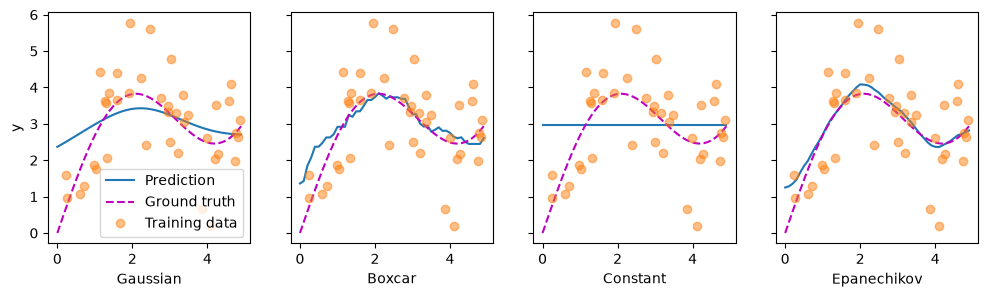

In [9]:
# Kernel Prediction Comparison

figure, axes = d2l.plt.subplots(
    1,
    4,
    sharey=True,
    figsize=(12, 3),
)


for kernel, name, axis in zip(
    kernels,
    kernel_names,
    axes,
    strict=True,
):
    predictions, _ = nadaraya_watson(
        x_train=x_train,
        y_train=y_train,
        queries=x_val,
        kernel=kernel,
    )

    # Kernel Regression Prediction
    axis.plot(
        x_val.detach().cpu().numpy(),
        predictions.detach().cpu().numpy(),
    )

    # Noise가 없는 Ground Truth
    axis.plot(
        x_val.detach().cpu().numpy(),
        y_val.detach().cpu().numpy(),
        "m--",
    )

    # Noise가 포함된 Training Data
    axis.plot(
        x_train.detach().cpu().numpy(),
        y_train.detach().cpu().numpy(),
        "o",
        alpha=0.5,
    )

    axis.set_xlabel(
        name
    )


axes[0].set_ylabel(
    "y"
)

axes[0].legend([
    "Prediction",
    "Ground truth",
    "Training data",
])

d2l.plt.show()

# Graph 해석:
# Gaussian   : 주변 Value를 부드럽게 결합
# Boxcar     : 일정 범위 안의 Value를 동일하게 결합
# Constant   : 모든 Value의 평균만 출력하므로 Query 변화에 반응하지 못함
# Epanechikov: 가까운 Value를 선형적으로 더 강하게 반영

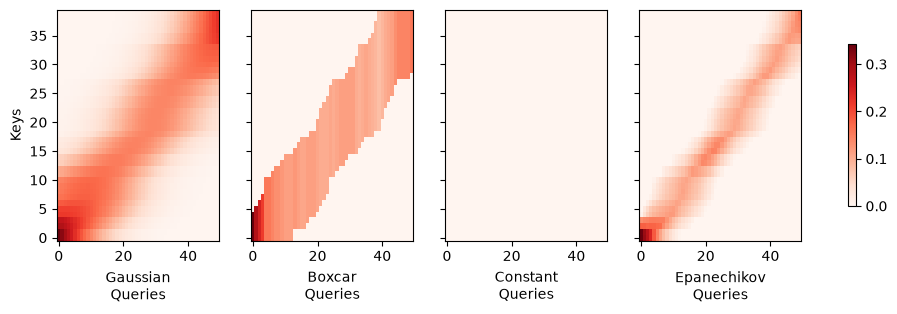

In [10]:
# Prediction 차이가 어떤 Attention Weight에서 발생했는지 확인
#
# Heatmap Row    : Training Key
# Heatmap Column : Validation Query
# 진한 색         : 높은 Attention Weight

figure, axes = d2l.plt.subplots(
    1,
    4,
    sharex=True,
    sharey=True,
    figsize=(12, 3),
)


last_image = None


for kernel, name, axis in zip(
    kernels,
    kernel_names,
    axes,
    strict=True,
):
    _, attention_weights = nadaraya_watson(
        x_train=x_train,
        y_train=y_train,
        queries=x_val,
        kernel=kernel,
    )

    last_image = axis.imshow(
        attention_weights.detach().cpu().numpy(),
        cmap="Reds",
        aspect="auto",
        origin="lower",
    )

    axis.set_xlabel(
        f"{name}\nQueries"
    )


axes[0].set_ylabel(
    "Keys"
)


if last_image is not None:
    figure.colorbar(
        last_image,
        ax=axes,
        shrink=0.7,
    )


d2l.plt.show()

# Heatmap 해석:
# Gaussian / Boxcar / Epanechikov
# Query와 가까운 Key 주변에 붉은 띠가 생김
# → Query 위치에 따라 사용하는 Value가 달라짐

# Constant
# 모든 위치가 거의 같은 색
# → 모든 Query가 모든 Value를 똑같이 평균냄